In [1]:
# imports
suppressPackageStartupMessages({
    library(data.table)
    library(Matrix)
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(ggthemes)
    library(tidyr)
    library(tibble)
    library(sf)
    library(sfarrow)
})

# Read and concatenate metadata

In [4]:
meta_files <- list(
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_CTRL-SYN-EDP1_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-EDP1_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-EDP2_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_PsD-SYN-EDP1_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-ARBITRATE_assay manifest.csv"
)

get_subset_and_edp <- function(path) {
  fname <- basename(path)
  # Extract everything between 'Xenium_' and '_assay manifest.csv'
  core <- sub("^Xenium_(.*)_assay manifest\\.csv$", "\\1", fname)
  if(core == "RA-SYN-ARBITRATE") {
      list(subset = "RA-SYN", cohort = "ARBITRATE") 
  }
  else {
      # Extract EDP (EDP1 or EDP2) from the core
      edp <- sub(".*-(EDP[12])$", "\\1", core)
      # Extract subset (everything before the last dash + EDP)
      subset <- sub(paste0("-", edp, "$"), "", core)
      list(subset = subset, cohort = edp)
  }
}

meta_list <- lapply(meta_files, function(f) {
  dt <- fread(f)
  info <- get_subset_and_edp(f)
  dt[, subset := info$subset]
  dt[, cohort := info$cohort]
  dt
})

metadata <- rbindlist(meta_list, use.names = TRUE, fill = TRUE)

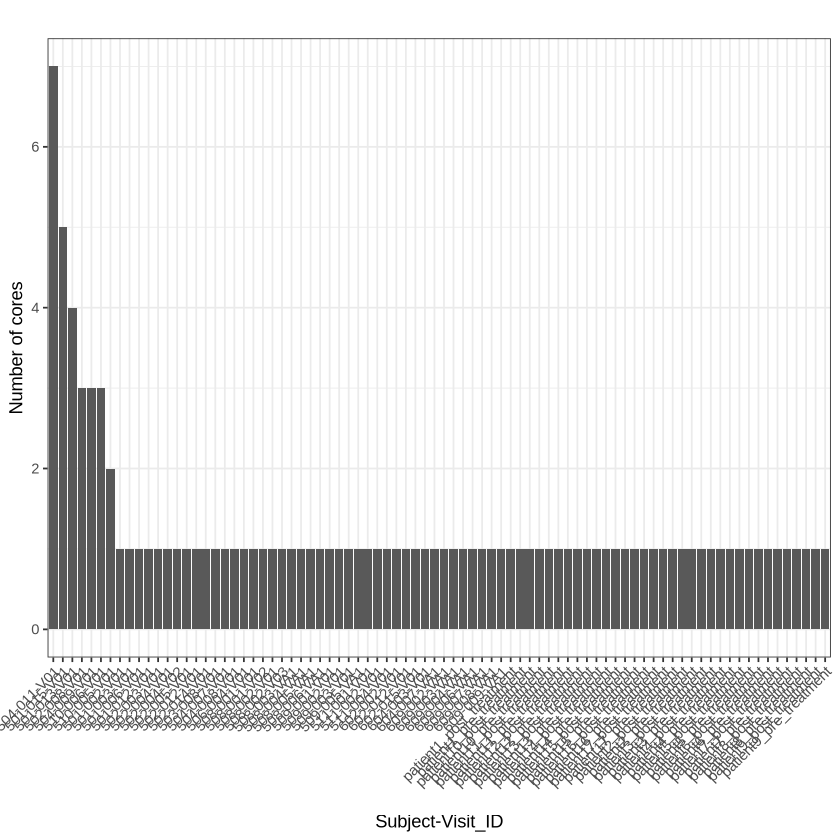

In [6]:
# count rows per Subject-Visit_ID
counts <- metadata[, .N, by = `Subject-Visit_ID`]

# optional: order by count
counts <- counts[order(-N)]

# bar plot
ggplot(counts, aes(x = reorder(`Subject-Visit_ID`, -N), y = N)) +
  geom_bar(stat = "identity") +
  labs(
    x = "Subject-Visit_ID",
    y = "Number of cores",
    title = ""
  ) +
  theme_bw(base_size = 18) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Merge Baysor output into Seurat object

In [8]:
cbind2_fill <- function(mat_list) {    
    rownames_all <- unique(unlist(lapply(mat_list, rownames)))
    
    add_list = list()
    for (i in seq_along(mat_list)) {
        cat("."); flush.console()
        mat <- mat_list[[i]]
        add_list[[i]] <- setdiff(rownames_all, rownames(mat))
        toadd <- Matrix::rsparsematrix(length(add_list[[i]]), ncol(mat), 0)
        mat_list[[i]] <- Matrix::rbind2(mat, toadd)
        rownames(mat_list[[i]]) <- c(rownames(mat), add_list[[i]])
        mat_list[[i]] <- mat_list[[i]][rownames_all, , drop = FALSE]
    }
    
    return(Reduce(Matrix::cbind2, mat_list))
}

In [ ]:
t0 <- Sys.time()  # global start time
sids <- unique(metadata$Sample_ID)

fov_list <- list()

for (sid in sids) {
  cohort <- metadata[metadata$Sample_ID == sid]$cohort[[1]]
  cat("\nProcessing sample:", sid, cohort, "\n")
  flush.console()

  pattern <- file.path("out", sid, "baysor_out", "*", "segmentation_counts.tsv")
  count_files <- Sys.glob(pattern)

  if (length(count_files) == 0) {
    warning(sprintf("No Baysor output found for sid: %s", sid))
    next
  }

  for (i in seq_along(count_files)) {
    cf <- count_files[[i]]
    cat(sprintf("\tFOV %d/%d: %s ", i, length(count_files), cf))
    flush.console()

    df <- read.csv(cf, sep = "\t", stringsAsFactors = FALSE, check.names = FALSE)
    gene_names <- df[[1]]
    cell_ids <- colnames(df)[-1]
    mat_sparse <- Matrix(as.matrix(df[, -1]), sparse = TRUE)

    rownames(mat_sparse) <- gene_names
    colnames(mat_sparse) <- paste0(cell_ids, "_", sid)
    fov_list[[cf]] <- mat_sparse

    # print total elapsed time in seconds
    elapsed <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
    cat(sprintf("(%.1f sec)\n", elapsed))
    flush.console()
  }
}

cat("concatenating...\n")
flush.console()
big <- cbind2_fill(fov_list)
big <- Seurat::CreateSeuratObject(
counts = big,
project = cohort
)
big[['sid']] <- sub(".*_", "", rownames(big[[]]))
saveRDS(big, file = "out_rds/allcells.rds")


Processing sample: 8073578341-02-02 EDP1 
	FOV 1/5: out/8073578341-02-02/baysor_out/F00000/segmentation_counts.tsv (42.5 sec)
	FOV 2/5: out/8073578341-02-02/baysor_out/F00001/segmentation_counts.tsv (58.2 sec)
	FOV 3/5: out/8073578341-02-02/baysor_out/F00002/segmentation_counts.tsv (74.9 sec)
	FOV 4/5: out/8073578341-02-02/baysor_out/F00003/segmentation_counts.tsv (93.9 sec)
	FOV 5/5: out/8073578341-02-02/baysor_out/F00004/segmentation_counts.tsv (138.4 sec)

Processing sample: 8073579095-02-02 EDP1 
	FOV 1/47: out/8073579095-02-02/baysor_out/F00000/segmentation_counts.tsv (145.8 sec)
	FOV 2/47: out/8073579095-02-02/baysor_out/F00001/segmentation_counts.tsv (154.4 sec)
	FOV 3/47: out/8073579095-02-02/baysor_out/F00002/segmentation_counts.tsv (168.0 sec)
	FOV 4/47: out/8073579095-02-02/baysor_out/F00003/segmentation_counts.tsv (175.4 sec)
	FOV 5/47: out/8073579095-02-02/baysor_out/F00004/segmentation_counts.tsv (195.1 sec)
	FOV 6/47: out/8073579095-02-02/baysor_out/F00005/segmentation_

# Add cell metadata to Seurat object

In [32]:
# big <- readRDS(file = "out_rds/allcells.rds")
t0 <- Sys.time()
sids <- unique(metadata$Sample_ID)

for (sid in sids) {
  cohort <- metadata[metadata$Sample_ID == sid, ]$cohort[[1]]
  cat("\nProcessing sample:", sid, cohort, "\n")
  flush.console()

  pattern <- file.path("out", sid, "baysor_out", "*", "segmentation_cell_stats.csv")
  count_files <- Sys.glob(pattern)

  if (length(count_files) == 0) {
    warning(sprintf("No Baysor output found for sid: %s", sid))
    next
  }

  for (i in seq_along(count_files)) {
    cf <- count_files[[i]]
    cat(sprintf("\tFOV %d/%d: %s ", i, length(count_files), cf))
    flush.console()

    df <- read.csv(cf, stringsAsFactors = FALSE, check.names = FALSE)

    # matching polygon file in same chunk dir
    poly_file <- file.path(dirname(cf), "segmentation_polygons_2d.json")
    if (!file.exists(poly_file)) {
      warning(sprintf("Missing polygon file for %s", cf))
      next
    }

    # read polygons
    geom <- st_read(poly_file, quiet = TRUE)

    # keep only id + polygon text
    geom_df <- data.frame(
      cell = geom$id,
      polygon_wkt = st_as_text(st_geometry(geom)),
      stringsAsFactors = FALSE
    )

    # merge polygon into cell metadata
    cellmeta <- merge(
      df[, c("cell", "x", "y", "avg_assignment_confidence")],
      geom_df,
      by = "cell",
      all.x = TRUE
    )

    # make Seurat cell names
    cellmeta$cell_full <- paste0(cellmeta$cell, "_", sid)

    # add into Seurat metadata
    big@meta.data[cellmeta$cell_full,
                  c("x", "y", "avg_assignment_confidence", "polygon_wkt")] <-
      cellmeta[, c("x", "y", "avg_assignment_confidence", "polygon_wkt")]

    elapsed <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
    cat(sprintf("(%.1f sec)\n", elapsed))
    flush.console()
  }
}

cat("Writing output...", "\n")
saveRDS(big, file = "out_rds/allcells.rds")


Processing sample: 8073578341-02-02 EDP1 
	FOV 1/5: out/8073578341-02-02/baysor_out/F00000/segmentation_cell_stats.csv (29.0 sec)
	FOV 2/5: out/8073578341-02-02/baysor_out/F00001/segmentation_cell_stats.csv (45.6 sec)
	FOV 3/5: out/8073578341-02-02/baysor_out/F00002/segmentation_cell_stats.csv (64.1 sec)
	FOV 4/5: out/8073578341-02-02/baysor_out/F00003/segmentation_cell_stats.csv (82.9 sec)
	FOV 5/5: out/8073578341-02-02/baysor_out/F00004/segmentation_cell_stats.csv (121.5 sec)

Processing sample: 8073579095-02-02 EDP1 
	FOV 1/47: out/8073579095-02-02/baysor_out/F00000/segmentation_cell_stats.csv (134.5 sec)
	FOV 2/47: out/8073579095-02-02/baysor_out/F00001/segmentation_cell_stats.csv (152.9 sec)
	FOV 3/47: out/8073579095-02-02/baysor_out/F00002/segmentation_cell_stats.csv (170.5 sec)
	FOV 4/47: out/8073579095-02-02/baysor_out/F00003/segmentation_cell_stats.csv (184.0 sec)
	FOV 5/47: out/8073579095-02-02/baysor_out/F00004/segmentation_cell_stats.csv (206.7 sec)
	FOV 6/47: out/80735790

# Unused (old)

In [ ]:
big <- readRDS(file = "out_rds/allcells.rds")
t0 <- Sys.time()  # global start time
sids <- unique(metadata$Sample_ID)

for (sid in sids) {
  cohort <- metadata[metadata$Sample_ID == sid]$cohort[[1]]
  cat("\nProcessing sample:", sid, cohort, "\n")
  flush.console()

  pattern <- file.path("out", sid, "baysor_out", "*", "segmentation_cell_stats.csv")
  count_files <- Sys.glob(pattern)

  if (length(count_files) == 0) {
    warning(sprintf("No Baysor output found for sid: %s", sid))
    next
  }

  for (i in seq_along(count_files)) {
    cf <- count_files[[i]]
    cat(sprintf("\tFOV %d/%d: %s ", i, length(count_files), cf))
    flush.console()

    df <- read.csv(cf, stringsAsFactors = FALSE, check.names = FALSE)
    cellmeta <- df[,c('x','y','avg_assignment_confidence')]
    cellmeta[['cell']] <- paste0(df$cell, "_", sid)
      
    # add in
    big@meta.data[cellmeta$cell, c('x','y','avg_assignment_confidence')] <- cellmeta[,c('x','y','avg_assignment_confidence')]

    # print total elapsed time in seconds
    elapsed <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
    cat(sprintf("(%.1f sec)\n", elapsed))
    flush.console()
  }
}
saveRDS(big, file = "out_rds/allcells.rds")